# Wigner crystal: structure, learnability and kernel reconstruction across crystallisation

Analysis of the Monte Carlo data of `generate_wc.py` (lattice one-component plasma, $19\times11$ commensurate box, $N=418$,
$760\times762$ grid, exact periodic Coulomb kernel). For every coupling $\Gamma$: order parameters and the structure factor, the second moment of the
regression design (learnability), and the closed-form reconstruction of the continuum kernel $V(q)$ from exact energies (and from energies with
$10^{-3}$ and $10^{-2}$ relative noise). 
The panel data for the main-text figure are exported to `Results_2D/Experiment_3/WC_data/`; everything else to `results/analysis.pt`.

In [1]:
import os, sys, math, glob, time, torch, numpy as np
sys.path.insert(0, os.path.abspath(".."))
from wc.lattice_wc import LatticeWC, A_LAT, WS_RADIUS
from wc.learn import RingBasis, fit_kernel, align, second_moment
torch.set_default_dtype(torch.float64)
DATA, RES, EXPORT = "data", "results", os.path.join("..", "Results_2D", "Experiment_3", "WC_data")
os.makedirs(RES, exist_ok=True); os.makedirs(EXPORT, exist_ok=True)
N_X, N_Y, M = 19, 11, 40; GAMMA_C = 115.0                                   # melting of the lattice-started system: 110 < Gamma < 120
Q_WC = 4 * math.pi / (math.sqrt(3) * A_LAT)                                 # first reciprocal-lattice vector of the triangular crystal
NOISE = (1e-3, 1e-2); N_VAL_CHAINS = 4; Q_CROP = 16.0
sim = LatticeWC(N_X, N_Y, M, 1.0, n_chains=1); N_s = sim.N_x * sim.N_y
lam_exact = torch.fft.rfft2(N_s * sim.psi).real                             # exact lattice kernel, K_0 = 0
rb = RingBasis(sim.N_x, sim.N_y, sim.L, lam_exact); lam_true = align(lam_exact, rb)
print(f"grid {sim.N_x}x{sim.N_y}, N={sim.N}, s={sim.s:.4f}={1/M:.3f} a_lat, a={WS_RADIUS:.4f}, a_lat={A_LAT:.4f}, q_WC={Q_WC:.3f}, "
      f"{rb.n_par} unknowns ({rb.n_exact} exact radii + interpolation knots + 1 alias amplitude; one direction is the gauge)")

grid 760x762, N=418, s=0.0269=0.025 a_lat, a=0.5642, a_lat=1.0746, q_WC=6.752, 361 unknowns (82 exact radii + interpolation knots + 1 alias amplitude; one direction is the gauge)


## Geometry of reciprocal space

Momenta live on the grid, $\mathbf q=2\pi(m_x/L_x,m_y/L_y)$ with integer indices $(m_x,m_y)$. The Bragg peaks of the
commensurate crystal sit at $(m_x,m_y)=(19h,\,11k)$ with $h+k$ even; the first shell $|\mathbf q|=q_{\rm WC}=4\pi/(\sqrt3\,a_{\rm lat})$
is the hexagon
$$(m_x,m_y)=(0,\pm22),\ (19,\pm11),\ (-19,\pm11).$$
The Bragg weight is $\langle S\rangle/N$ averaged over the first shell; the diffuse weight is the mean of $\langle S(\mathbf q)\rangle$
over $0<|\mathbf q|<2q_{\rm WC}$ excluding the Bragg points.

In [2]:
cx, cy = sim.N_x // 2, sim.N_y // 2; dqx, dqy = 2 * math.pi / float(sim.L[0]), 2 * math.pi / float(sim.L[1])
qx = (np.arange(sim.N_x) - cx) * dqx; qy = (np.arange(sim.N_y) - cy) * dqy; QX, QY = np.meshgrid(qx, qy, indexing="ij"); Qn = np.hypot(QX, QY)
bragg = np.zeros_like(Qn, bool); shell1 = []
for m1 in range(-9, 10):
    for m2 in range(-9, 10):
        ix, iy = cx + 19 * m1, cy + 11 * (m1 + 2 * m2)
        if 0 <= ix < sim.N_x and 0 <= iy < sim.N_y:
            bragg[ix, iy] = True
            if abs(np.hypot(qx[ix], qy[iy]) - Q_WC) < 0.05: shell1.append((ix, iy))
diffuse_mask = (Qn < 2 * Q_WC) & ~bragg & (Qn > 0)
ix_crop = np.abs(qx) <= Q_CROP; iy_crop = np.abs(qy) <= Q_CROP
print(len(shell1), "first-shell Bragg points;", int(diffuse_mask.sum()), "diffuse momenta; crop", int(ix_crop.sum()), "x", int(iy_crop.sum()))

6 first-shell Bragg points; 6044 diffuse momenta; crop 103 x 105


## Per-coupling analysis

The first quarter of every chain is discarded as equilibration. The last `N_VAL_CHAINS` chains are the validation set; the rest form the training set.
Errors: normalised energy error = RMS residual over the standard deviation of the training energies (training set and validation set);
kernel error $=\max_{\mathbf q}|\lambda^{\rm learned}_{\mathbf q}-\lambda_{\mathbf q}|/\max_{\mathbf q}|\lambda_{\mathbf q}|$ on the full grid after both
kernels are brought to the gauge $\lambda_0=0$, $\sum_{\mathbf q\ne0}\lambda_{\mathbf q}=0$; also quoted within $|\mathbf q|<3$, $|\,|\mathbf q|-q_{\rm WC}|<0.5$ and $12<|\mathbf q|<40$.

In [ ]:
def analyse(f):
    d = torch.load(f); G = float(d["Gamma"]); t0 = time.time()
    pos = d["pos"].long(); T0 = pos.shape[0]; pos, E = pos[T0 // 4:], d["E"][T0 // 4:]; T, C = pos.shape[:2]
    # ---- structure ----
    sub = pos[:: max(1, T // 25)].reshape(-1, sim.N, 2)
    S = rb.mean_structure_factor(sub, sim).numpy()                                             # fftshifted, S(0) = 0
    bragg_w = float(np.mean([S[i] for i in shell1])) / sim.N; diffuse_w = float(S[diffuse_mask].mean())
    # ---- learning ----
    Ct = C - N_VAL_CHAINS
    X = rb.design(pos[:, :Ct].reshape(-1, sim.N, 2), sim); y = E[:, :Ct].reshape(-1)
    X_va = rb.design(pos[:, Ct:].reshape(-1, sim.N, 2), sim); y_va = E[:, Ct:].reshape(-1)
    ev = second_moment(X); n_above = int((ev > 1e-6).sum())
    fits = {}; g = torch.Generator().manual_seed(int(10 * G))
    for rel in (0.0,) + NOISE:
        theta, c = fit_kernel(X, y + rel * y.std() * torch.randn(len(y), generator=g))
        lam = align(rb.lam_from_theta(theta), rb); err = (lam - lam_true).abs() / lam_true.abs().max(); q = rb.q
        win = lambda m: float(err[m].max())
        fits[rel] = dict(theta=theta, c=c, train=float((X @ theta + c - y).pow(2).mean().sqrt() / y.std()),
                         val=float((X_va @ theta + c - y_va).pow(2).mean().sqrt() / y.std()),
                         err=float(err.max()), err_lowq=win((q > 0) & (q < 3)), err_wc=win((q - Q_WC).abs() < 0.5), err_highq=win((q > 12) & (q < 40)),
                         V=rb.V_knots(theta), mu_inf=float(theta[-1] / rb.theta_exact()[-1]))
    # jackknife of the rank over 4 chain groups
    jk = []
    for grp in range(4):
        keep = torch.tensor([c_ for c_ in range(Ct) if c_ % 4 != grp])
        Xs = X.view(T, Ct, -1)[:, keep].reshape(-1, X.shape[1]); jk.append(int((second_moment(Xs) > 1e-6).sum()))
    jk = np.array(jk, float); n_above_err = float(np.sqrt(3 / 4 * ((jk - jk.mean()) ** 2).sum()))
    fe = fits[0.0]
    print(f"Gamma={G:6g} T/Tc={GAMMA_C / G:6.3f}  E/N={float(E.mean()) / sim.N:.5f}  S_peak={S.max():6.1f}  Bragg={bragg_w:.3f} diffuse={diffuse_w:.3f}  "
          f"delta/a_lat={d['delta'] / A_LAT:.3f}  tau={d['tau']:5.0f}  rank(>1e-6)={n_above:3d}+-{n_above_err:.0f}/{rb.n_par}  "
          f"exact: train {fe['train']:.0e} validation {fe['val']:.0e} kernel err {fe['err']:.1e} (q<3 {fe['err_lowq']:.1e}, q~q_WC {fe['err_wc']:.1e}, 12<q<40 {fe['err_highq']:.1e}) mu_inf/2pi={fe['mu_inf']:.8f};  "
          f"1% noise: kernel err {fits[1e-2]['err']:.1e}   [{time.time() - t0:.0f}s]", flush=True)
    return dict(Gamma=G, T=GAMMA_C / G, E=float(E.mean()) / sim.N, S_peak=float(S.max()), bragg=bragg_w, diffuse=diffuse_w, delta=float(d["delta"] / A_LAT), tau=float(d["tau"]),
                acc=float(d["acc"]), S_crop=S[np.ix_(ix_crop, iy_crop)], snap=(pos[-1, 0].double() * sim.s).numpy(), ev=ev.numpy(), n_above=n_above, n_above_err=n_above_err,
                fits=fits, E_std=float(y.std()), n_train=len(y), n_val=len(y_va))

results = {}
for f in sorted(glob.glob(os.path.join(DATA, "G*.pt")), key=lambda f: float(os.path.basename(f)[1:-3])):
    r = analyse(f); results[r["Gamma"]] = r
gammas = sorted(results)
torch.save(dict(results=results, q_knots=rb.q_knots, lam_true=lam_true, GAMMA_C=GAMMA_C, Q_WC=Q_WC), os.path.join(RES, "analysis.pt"))

Gamma=    46 T/Tc= 2.500  E/N=-1.91799  S_peak=   2.5  Bragg=0.006 diffuse=0.925  delta/a_lat=0.171  tau=   16  rank(>1e-6)=352+-0/361  exact: train 4e-11 validation 4e-11 kernel err 4.0e-11 (q<3 4.0e-11, q~q_WC 1.5e-11, 12<q<40 3.7e-11) mu_inf/2pi=1.00000000;  1% noise: kernel err 1.5e-02   [88s]
Gamma=    73 T/Tc= 1.575  E/N=-1.93081  S_peak=   3.3  Bragg=0.007 diffuse=0.938  delta/a_lat=0.155  tau=   28  rank(>1e-6)=351+-0/361  exact: train 6e-11 validation 6e-11 kernel err 1.3e-10 (q<3 1.3e-10, q~q_WC 5.3e-11, 12<q<40 8.9e-12) mu_inf/2pi=1.00000000;  1% noise: kernel err 8.1e-03   [87s]
Gamma=    87 T/Tc= 1.322  E/N=-1.93467  S_peak=   3.7  Bragg=0.008 diffuse=0.944  delta/a_lat=0.148  tau=   49  rank(>1e-6)=351+-0/361  exact: train 7e-11 validation 8e-11 kernel err 1.5e-10 (q<3 7.6e-11, q~q_WC 1.3e-10, 12<q<40 1.5e-10) mu_inf/2pi=1.00000001;  1% noise: kernel err 7.9e-03   [85s]
Gamma=   110 T/Tc= 1.045  E/N=-1.93995  S_peak=  27.5  Bragg=0.064 diffuse=0.932  delta/a_lat=0.136  ta

## Quick look

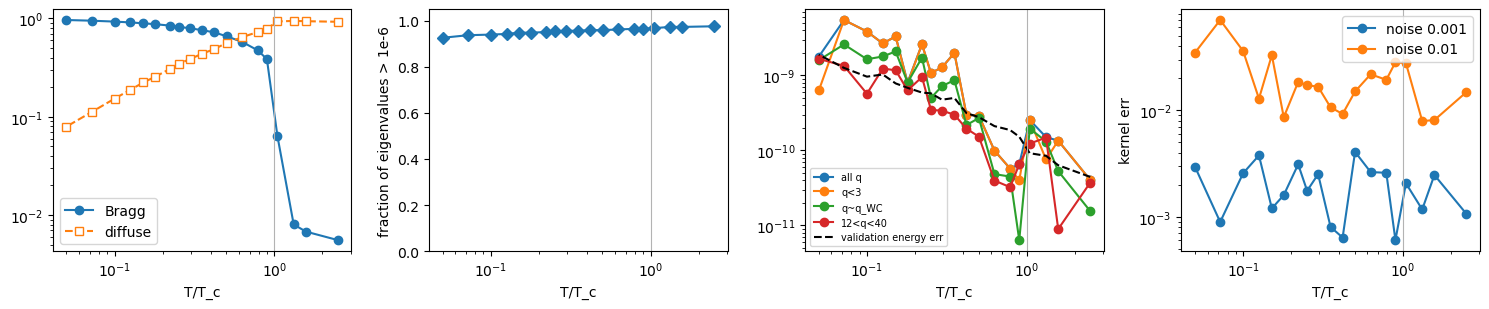

In [4]:
import matplotlib.pyplot as plt
T = np.array([results[G]["T"] for G in gammas])
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
ax[0].plot(T, [results[G]["bragg"] for G in gammas], "o-", label="Bragg"); ax[0].plot(T, [results[G]["diffuse"] for G in gammas], "s--", mfc="w", label="diffuse")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_xlabel("T/T_c"); ax[0].legend()
ax[1].plot(T, [results[G]["n_above"] / rb.n_par for G in gammas], "D-"); ax[1].set_xscale("log"); ax[1].set_xlabel("T/T_c"); ax[1].set_ylabel("fraction of eigenvalues > 1e-6"); ax[1].set_ylim(0, 1.05)
for key, lab in [("err", "all q"), ("err_lowq", "q<3"), ("err_wc", "q~q_WC"), ("err_highq", "12<q<40")]:
    ax[2].semilogy(T, [results[G]["fits"][0.0][key] for G in gammas], "o-", label=lab)
ax[2].semilogy(T, [results[G]["fits"][0.0]["val"] for G in gammas], "k--", label="validation energy err"); ax[2].set_xscale("log"); ax[2].set_xlabel("T/T_c"); ax[2].legend(fontsize=7)
for rel in NOISE: ax[3].semilogy(T, [results[G]["fits"][rel]["err"] for G in gammas], "o-", label=f"noise {rel:g}")
ax[3].set_xscale("log"); ax[3].set_xlabel("T/T_c"); ax[3].set_ylabel("kernel err"); ax[3].legend()
for a in ax: a.axvline(1, c="0.7", lw=0.8)
plt.tight_layout(); plt.show()

## Export for the main-text figure (`Results_2D/Experiment_3/WC_data/`)

Snapshot points: the liquid at $\Gamma=46$ ($T=2.5\,T_c$) and the crystal at $\Gamma=274$ ($T=0.42\,T_c$); the reconstruction is shown at $\Gamma=274$.

In [5]:
G_hi, G_lo = 46.0, 274.0
np.savez(os.path.join(EXPORT, "snapshots.npz"), L_x=float(sim.L[0]), L_y=float(sim.L[1]), N=sim.N, Gamma_c=GAMMA_C, q_WC=Q_WC, a_lat=A_LAT,
         qx=qx[ix_crop], qy=qy[iy_crop], **{f"{k}_{tag}": v for tag, G in (("high", G_hi), ("low", G_lo))
                                              for k, v in (("Gamma", G), ("T", GAMMA_C / G), ("pos", results[G]["snap"]), ("S", results[G]["S_crop"]))})
np.savez(os.path.join(EXPORT, "weights.npz"), Gamma=np.array(gammas), T=T, bragg=np.array([results[G]["bragg"] for G in gammas]), diffuse=np.array([results[G]["diffuse"] for G in gammas]),
         S_peak=np.array([results[G]["S_peak"] for G in gammas]), delta=np.array([results[G]["delta"] for G in gammas]), tau=np.array([results[G]["tau"] for G in gammas]), Gamma_c=GAMMA_C)
np.savez(os.path.join(EXPORT, "rank.npz"), Gamma=np.array(gammas), T=T, eigenvalues=np.stack([results[G]["ev"] for G in gammas]), n_unknowns=rb.n_par,
         n_above_1e6=np.array([results[G]["n_above"] for G in gammas]), n_above_1e6_err=np.array([results[G]["n_above_err"] for G in gammas]), Gamma_c=GAMMA_C)
fe = results[G_lo]["fits"][0.0]; qk = rb.q_knots[:-1].numpy()
edges = np.concatenate([[0], np.sort(qk)[:rb.n_exact] + 1e-6, np.arange(3.05, 80.0, 0.1)])         # exact radii, then 0.1 bins
lt_r, ok = rb.ring_average(lam_true, torch.tensor(edges)); lf_r, _ = rb.ring_average(align(rb.lam_from_theta(fe["theta"]), rb), torch.tensor(edges))
q_r = torch.tensor(0.5 * (edges[1:] + edges[:-1]))
np.savez(os.path.join(EXPORT, "reconstruction.npz"), Gamma=G_lo, T=GAMMA_C / G_lo, Gamma_c=GAMMA_C, q_knots=qk, V_true=2 * math.pi / qk, V_learned=fe["V"].numpy(), mu_inf_over_2pi=fe["mu_inf"],
         q_rings=q_r.numpy()[ok.numpy()], lam_true_rings=lt_r.numpy()[ok.numpy()], lam_learned_rings=lf_r.numpy()[ok.numpy()],
         kernel_err=fe["err"], energy_err_train=fe["train"], energy_err_validation=fe["val"], n_train=results[G_lo]["n_train"], n_val=results[G_lo]["n_val"])
print("exported to", EXPORT, ":", sorted(os.listdir(EXPORT)))

exported to ../Results_2D/Experiment_3/WC_data : ['rank.npz', 'reconstruction.npz', 'snapshots.npz', 'weights.npz']
